In [1]:
# CELL 1: Import libraries and locate Transport Activity Count files

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Main folder containing the downloaded datasets
base_path = Path(
    r"C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After"
)

# Search all TransportActivityCount folders for CSV files
activity_files = sorted(
    base_path.glob("TransportActivityCount_*/*.csv")
)

print("Number of CSV files found:", len(activity_files))

print("\nFirst few files found:")
for file in activity_files[:10]:
    print(file)

if len(activity_files) == 0:
    print("\nWARNING: No CSV files were found. Check the folder names and path.")

Number of CSV files found: 14

First few files found:
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\TransportActivityCount_2023\TransportActivityCount_2023-1.csv
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\TransportActivityCount_2023\TransportActivityCount_2023-2.csv
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\TransportActivityCount_2023\TransportActivityCount_2023-3.csv
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\TransportActivityCount_2023\TransportActivityCount_2023-4.csv
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\TransportActivityCount_2024\TransportActivityCount_2024-1.csv
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\TransportActivityCount_2024\TransportActivityCount_2024-2.csv
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\TransportActivityCount_2024\TransportActivityCount_2024-3.csv
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\TransportActivityCount_2024\TransportActivityCount_2024-4.csv
C:\Users\LENOVO\Desktop\Pr

In [3]:
# CELL 2: Inspect one Transport Activity Count CSV file

sample_file = activity_files[0]

print("Sample file being inspected:")
print(sample_file)

# Read the first CSV
sample_df = pd.read_csv(sample_file, low_memory=False)

print("\nDATASET SIZE")
print("Rows:", sample_df.shape[0])
print("Columns:", sample_df.shape[1])

print("\nCOLUMN NAMES")
for number, column in enumerate(sample_df.columns, start=1):
    print(f"{number}. {column}")

print("\nFIRST 5 ROWS")
display(sample_df.head())

print("\nDATA TYPES")
print(sample_df.dtypes)

Sample file being inspected:
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\TransportActivityCount_2023\TransportActivityCount_2023-1.csv

DATASET SIZE
Rows: 460122
Columns: 11

COLUMN NAMES
1. countLocationId
2. countlineName
3. countlineDirection
4. CountLocationLat
5. CountLocationLong
6. from
7. to
8. class
9. count
10. year
11. quarter

FIRST 5 ROWS


,countLocationId,countlineName,countlineDirection,CountLocationLat,CountLocationLong,from,to,class,count,year,quarter
0,43891,s2_Swanston_crossing_bn001,CLOCKWISE_AND_ANTICLOCKWISE,-37.807686,144.962799,2023-01-03T15:10:00.000Z,2023-01-03T15:15:00.000Z,pedestrian,6,2023,1
1,45038,S4_QueensBridgeSt_Road_bn003,CLOCKWISE_ONLY,-37.820930,144.961639,2023-01-07T15:00:00.000Z,2023-01-07T15:05:00.000Z,car,26,2023,1
2,43772,s1_SouthbankPromenade_bn001,CLOCKWISE_AND_ANTICLOCKWISE,-37.820171,144.965088,2023-01-09T11:00:00.000Z,2023-01-09T11:05:00.000Z,cyclist,6,2023,1
3,45038,S4_QueensBridgeSt_Road_bn003,CLOCKWISE_ONLY,-37.820930,144.961639,2023-01-10T13:30:00.000Z,2023-01-10T13:35:00.000Z,van,1,2023,1
4,43775,s2_Swanston_cyclelane_bn001,CLOCKWISE_AND_ANTICLOCKWISE,-37.807686,144.962799,2023-01-11T08:30:00.000Z,2023-01-11T08:35:00.000Z,pedestrian,3,2023,1



DATA TYPES
countLocationId         int64
countlineName          object
countlineDirection     object
CountLocationLat      float64
CountLocationLong     float64
from                   object
to                     object
class                  object
count                   int64
year                    int64
quarter                 int64
dtype: object


In [5]:
# CELL 3: Validate the structure of all 14 Transport Activity Count files

file_summary = []

for file in activity_files:
    
    # Read only the header first
    header = pd.read_csv(file, nrows=0)
    
    # Count rows without loading the whole file into memory
    with open(file, "r", encoding="utf-8") as f:
        row_count = sum(1 for _ in f) - 1
    
    file_summary.append({
        "Folder": file.parent.name,
        "File": file.name,
        "Rows": row_count,
        "Columns": len(header.columns),
        "Column_Structure": tuple(header.columns)
    })

file_summary_df = pd.DataFrame(file_summary)

print("=" * 60)
print("FILE STRUCTURE CHECK")
print("=" * 60)

print("\nTotal files checked:", len(file_summary_df))

print(
    "Different column structures:",
    file_summary_df["Column_Structure"].nunique()
)

print("\nFILE-BY-FILE SUMMARY")

display(
    file_summary_df[
        ["Folder", "File", "Rows", "Columns"]
    ]
)

print("\nTOTAL ROWS ACROSS ALL FILES")

print(
    file_summary_df["Rows"].sum()
)

print("\nCOLUMN STRUCTURES FOUND")

for i, structure in enumerate(
    file_summary_df["Column_Structure"].unique(),
    start=1
):
    print(f"\nStructure {i}:")
    print(list(structure))

FILE STRUCTURE CHECK

Total files checked: 14
Different column structures: 1

FILE-BY-FILE SUMMARY


,Folder,File,Rows,Columns
0,TransportActivityCount_2023,TransportActivityCount_2023-1.csv,460122,11
1,TransportActivityCount_2023,TransportActivityCount_2023-2.csv,847336,11
2,TransportActivityCount_2023,TransportActivityCount_2023-3.csv,993907,11
3,TransportActivityCount_2023,TransportActivityCount_2023-4.csv,1074945,11
4,TransportActivityCount_2024,TransportActivityCount_2024-1.csv,1145303,11
5,TransportActivityCount_2024,TransportActivityCount_2024-2.csv,1198567,11
6,TransportActivityCount_2024,TransportActivityCount_2024-3.csv,1304016,11
7,TransportActivityCount_2024,TransportActivityCount_2024-4.csv,1304593,11
8,TransportActivityCount_2025,TransportActivityCount_2025-1.csv,1235120,11
9,TransportActivityCount_2025,TransportActivityCount_2025-2.csv,1333856,11



TOTAL ROWS ACROSS ALL FILES
22347087

COLUMN STRUCTURES FOUND

Structure 1:
['countLocationId', 'countlineName', 'countlineDirection', 'CountLocationLat', 'CountLocationLong', 'from', 'to', 'class', 'count', 'year', 'quarter']


In [7]:
# CELL 4: Memory-efficient overview of the complete 2023-2026 dataset

from collections import Counter

chunk_size = 200_000

year_records = Counter()
quarter_records = Counter()
class_records = Counter()
class_activity = Counter()

unique_locations = set()

earliest_date = None
latest_date = None

invalid_from_dates = 0
processed_rows = 0

for file in activity_files:
    
    print("Processing:", file.name)
    
    for chunk in pd.read_csv(
        file,
        chunksize=chunk_size,
        low_memory=False
    ):
        
        processed_rows += len(chunk)
        
        # Convert the starting timestamp
        dates = pd.to_datetime(
            chunk["from"],
            errors="coerce",
            utc=True
        )
        
        invalid_from_dates += dates.isna().sum()
        
        valid_dates = dates.dropna()
        
        if not valid_dates.empty:
            
            chunk_min = valid_dates.min()
            chunk_max = valid_dates.max()
            
            if earliest_date is None or chunk_min < earliest_date:
                earliest_date = chunk_min
                
            if latest_date is None or chunk_max > latest_date:
                latest_date = chunk_max
        
        # Count records by year and quarter
        year_records.update(
            chunk["year"].dropna().astype(str)
        )
        
        quarter_records.update(
            zip(chunk["year"], chunk["quarter"])
        )
        
        # Find all unique counting locations
        unique_locations.update(
            chunk["countLocationId"].dropna().unique()
        )
        
        # Count records belonging to each transport class
        class_records.update(
            chunk["class"].dropna().astype(str)
        )
        
        # Calculate actual activity totals for each class
        class_totals = (
            chunk.groupby("class")["count"].sum()
        )
        
        for activity_class, total in class_totals.items():
            class_activity[activity_class] += total


print("\n" + "=" * 60)
print("COMPLETE DATASET OVERVIEW")
print("=" * 60)

print("Rows processed:", f"{processed_rows:,}")
print("Earliest timestamp:", earliest_date)
print("Latest timestamp:", latest_date)
print("Invalid 'from' timestamps:", f"{invalid_from_dates:,}")
print("Unique count locations:", f"{len(unique_locations):,}")

print("\nRECORDS BY YEAR")
for year, number in sorted(year_records.items()):
    print(year, ":", f"{number:,}")

print("\nTRANSPORT CLASSES")
for activity_class, number in class_records.most_common():
    print(activity_class, ":", f"{number:,}", "records")

print("\nTOTAL COUNTS BY TRANSPORT CLASS")
for activity_class, total in class_activity.most_common():
    print(activity_class, ":", f"{total:,}")

Processing: TransportActivityCount_2023-1.csv
Processing: TransportActivityCount_2023-2.csv
Processing: TransportActivityCount_2023-3.csv
Processing: TransportActivityCount_2023-4.csv
Processing: TransportActivityCount_2024-1.csv
Processing: TransportActivityCount_2024-2.csv
Processing: TransportActivityCount_2024-3.csv
Processing: TransportActivityCount_2024-4.csv
Processing: TransportActivityCount_2025-1.csv
Processing: TransportActivityCount_2025-2.csv
Processing: TransportActivityCount_2025-3.csv
Processing: TransportActivityCount_2025-4.csv
Processing: TransportActivityCount_2026-1.csv
Processing: TransportActivityCount_2026-2.csv

COMPLETE DATASET OVERVIEW
Rows processed: 22,347,087
Earliest timestamp: 2023-01-01 00:00:00+00:00
Latest timestamp: 2026-05-11 15:55:00+00:00
Invalid 'from' timestamps: 0
Unique count locations: 167

RECORDS BY YEAR
2023 : 3,376,310
2024 : 4,952,479
2025 : 5,812,928
2026 : 8,205,370

TRANSPORT CLASSES
pedestrian : 7,403,878 records
cyclist : 5,149,317 

In [9]:
# CELL 5: Missing values and basic data-quality checks

missing_values = Counter()

total_rows = 0
negative_counts = 0
zero_counts = 0

invalid_latitude = 0
invalid_longitude = 0

for file in activity_files:
    
    print("Checking:", file.name)
    
    for chunk in pd.read_csv(
        file,
        chunksize=200_000,
        low_memory=False
    ):
        
        total_rows += len(chunk)
        
        # Count missing values in every column
        for column, value in chunk.isna().sum().items():
            missing_values[column] += int(value)
        
        # Check the activity count field
        negative_counts += (chunk["count"] < 0).sum()
        zero_counts += (chunk["count"] == 0).sum()
        
        # Melbourne latitude/longitude should still be within
        # normal geographic coordinate ranges.
        invalid_latitude += (
            (chunk["CountLocationLat"] < -90) |
            (chunk["CountLocationLat"] > 90)
        ).sum()
        
        invalid_longitude += (
            (chunk["CountLocationLong"] < -180) |
            (chunk["CountLocationLong"] > 180)
        ).sum()


# Build a readable missing-value table
missing_summary = pd.DataFrame({
    "Column": list(missing_values.keys()),
    "Missing_Values": list(missing_values.values())
})

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Values"] / total_rows * 100
).round(4)

missing_summary = missing_summary.sort_values(
    "Missing_Values",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 65)
print("DATA QUALITY SUMMARY")
print("=" * 65)

print("\nTotal rows checked:", f"{total_rows:,}")

print("\nMISSING VALUES")
display(missing_summary)

print("\nCOUNT FIELD CHECK")
print("Negative counts:", f"{negative_counts:,}")
print("Zero counts:", f"{zero_counts:,}")

print("\nCOORDINATE CHECK")
print("Invalid latitude values:", f"{invalid_latitude:,}")
print("Invalid longitude values:", f"{invalid_longitude:,}")

Checking: TransportActivityCount_2023-1.csv
Checking: TransportActivityCount_2023-2.csv
Checking: TransportActivityCount_2023-3.csv
Checking: TransportActivityCount_2023-4.csv
Checking: TransportActivityCount_2024-1.csv
Checking: TransportActivityCount_2024-2.csv
Checking: TransportActivityCount_2024-3.csv
Checking: TransportActivityCount_2024-4.csv
Checking: TransportActivityCount_2025-1.csv
Checking: TransportActivityCount_2025-2.csv
Checking: TransportActivityCount_2025-3.csv
Checking: TransportActivityCount_2025-4.csv
Checking: TransportActivityCount_2026-1.csv
Checking: TransportActivityCount_2026-2.csv

DATA QUALITY SUMMARY

Total rows checked: 22,347,087

MISSING VALUES


,Column,Missing_Values,Missing_Percentage
0,countlineName,5604,0.0251
1,countlineDirection,5604,0.0251
2,CountLocationLat,5604,0.0251
3,CountLocationLong,5604,0.0251
4,countLocationId,0,0.0000
5,from,0,0.0000
6,to,0,0.0000
7,class,0,0.0000
8,count,0,0.0000
9,year,0,0.0000



COUNT FIELD CHECK
Negative counts: 0
Zero counts: 0

COORDINATE CHECK
Invalid latitude values: 0
Invalid longitude values: 0


Checking locations: TransportActivityCount_2023-1.csv
Checking locations: TransportActivityCount_2023-2.csv
Checking locations: TransportActivityCount_2023-3.csv
Checking locations: TransportActivityCount_2023-4.csv
Checking locations: TransportActivityCount_2024-1.csv
Checking locations: TransportActivityCount_2024-2.csv
Checking locations: TransportActivityCount_2024-3.csv
Checking locations: TransportActivityCount_2024-4.csv
Checking locations: TransportActivityCount_2025-1.csv
Checking locations: TransportActivityCount_2025-2.csv
Checking locations: TransportActivityCount_2025-3.csv
Checking locations: TransportActivityCount_2025-4.csv
Checking locations: TransportActivityCount_2026-1.csv
Checking locations: TransportActivityCount_2026-2.csv

COUNT LOCATION COVERAGE


,Year,Unique_Count_Locations
0,2023,32
1,2024,34
2,2025,85
3,2026,159



NEW LOCATIONS COMPARED WITH PREVIOUS YEAR

2024 compared with 2023:
New locations: 2
Locations no longer present: 0

2025 compared with 2024:
New locations: 51
Locations no longer present: 0

2026 compared with 2025:
New locations: 82
Locations no longer present: 8


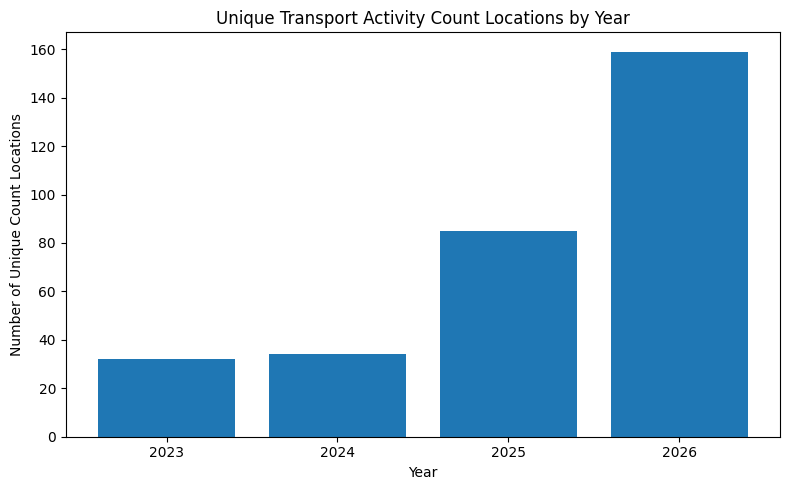

In [11]:
# CELL 6: Analyse count-location coverage across years

locations_by_year = {}
location_names = {}
location_coordinates = {}

for file in activity_files:
    
    print("Checking locations:", file.name)
    
    for chunk in pd.read_csv(
        file,
        chunksize=200_000,
        low_memory=False
    ):
        
        # Number of unique locations operating in each year
        for year, group in chunk.groupby("year"):
            
            if year not in locations_by_year:
                locations_by_year[year] = set()
            
            locations_by_year[year].update(
                group["countLocationId"].dropna().unique()
            )
        
        # Keep a representative name and coordinate for each location
        location_info = (
            chunk[
                [
                    "countLocationId",
                    "countlineName",
                    "CountLocationLat",
                    "CountLocationLong"
                ]
            ]
            .drop_duplicates(subset="countLocationId")
        )
        
        for _, row in location_info.iterrows():
            
            location_id = row["countLocationId"]
            
            if location_id not in location_names:
                location_names[location_id] = row["countlineName"]
                
            if location_id not in location_coordinates:
                location_coordinates[location_id] = (
                    row["CountLocationLat"],
                    row["CountLocationLong"]
                )


# Create year summary
coverage_summary = []

for year in sorted(locations_by_year):
    
    coverage_summary.append({
        "Year": year,
        "Unique_Count_Locations": len(locations_by_year[year])
    })

coverage_df = pd.DataFrame(coverage_summary)

print("\n" + "=" * 60)
print("COUNT LOCATION COVERAGE")
print("=" * 60)

display(coverage_df)


# Compare locations between years
print("\nNEW LOCATIONS COMPARED WITH PREVIOUS YEAR")

years = sorted(locations_by_year)

for i in range(1, len(years)):
    
    previous_year = years[i - 1]
    current_year = years[i]
    
    new_locations = (
        locations_by_year[current_year]
        - locations_by_year[previous_year]
    )
    
    removed_locations = (
        locations_by_year[previous_year]
        - locations_by_year[current_year]
    )
    
    print(
        f"\n{current_year} compared with {previous_year}:"
    )
    
    print("New locations:", len(new_locations))
    print("Locations no longer present:", len(removed_locations))


# Simple visualisation
plt.figure(figsize=(8, 5))

plt.bar(
    coverage_df["Year"].astype(str),
    coverage_df["Unique_Count_Locations"]
)

plt.title("Unique Transport Activity Count Locations by Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Count Locations")

plt.tight_layout()
plt.show()

In [13]:
# CELL 7: Check duplicates and validate observation intervals

total_duplicates = 0
interval_counts = Counter()
invalid_intervals = 0
total_checked = 0

# Columns that together describe an observation
duplicate_columns = [
    "countLocationId",
    "countlineName",
    "countlineDirection",
    "from",
    "to",
    "class",
    "count"
]

for file in activity_files:

    print("Checking:", file.name)

    # Read one quarterly file at a time
    df_temp = pd.read_csv(
        file,
        low_memory=False
    )

    total_checked += len(df_temp)

    # -----------------------------
    # Duplicate check
    # -----------------------------
    duplicates = df_temp.duplicated(
        subset=duplicate_columns
    ).sum()

    total_duplicates += duplicates

    # -----------------------------
    # Time interval check
    # -----------------------------
    from_time = pd.to_datetime(
        df_temp["from"],
        errors="coerce",
        utc=True
    )

    to_time = pd.to_datetime(
        df_temp["to"],
        errors="coerce",
        utc=True
    )

    interval_minutes = (
        (to_time - from_time)
        .dt.total_seconds()
        .div(60)
    )

    # Count different interval lengths
    interval_counts.update(
        interval_minutes.dropna().value_counts().to_dict()
    )

    # Anything other than 5 minutes
    invalid_intervals += (
        interval_minutes != 5
    ).sum()

    # Remove temporary dataframe before next file
    del df_temp


print("\n" + "=" * 60)
print("DUPLICATE AND TIME INTERVAL CHECK")
print("=" * 60)

print("\nTotal rows checked:", f"{total_checked:,}")

print("\nDUPLICATES")
print("Potential duplicate observations:", f"{total_duplicates:,}")

duplicate_percentage = (
    total_duplicates / total_checked * 100
)

print(
    "Duplicate percentage:",
    f"{duplicate_percentage:.4f}%"
)

print("\nOBSERVATION INTERVALS")

for minutes, number in sorted(interval_counts.items()):
    print(
        f"{minutes} minutes:",
        f"{number:,}",
        "records"
    )

print(
    "\nRecords not using a 5-minute interval:",
    f"{invalid_intervals:,}"
)

Checking: TransportActivityCount_2023-1.csv
Checking: TransportActivityCount_2023-2.csv
Checking: TransportActivityCount_2023-3.csv
Checking: TransportActivityCount_2023-4.csv
Checking: TransportActivityCount_2024-1.csv
Checking: TransportActivityCount_2024-2.csv
Checking: TransportActivityCount_2024-3.csv
Checking: TransportActivityCount_2024-4.csv
Checking: TransportActivityCount_2025-1.csv
Checking: TransportActivityCount_2025-2.csv
Checking: TransportActivityCount_2025-3.csv
Checking: TransportActivityCount_2025-4.csv
Checking: TransportActivityCount_2026-1.csv
Checking: TransportActivityCount_2026-2.csv

DUPLICATE AND TIME INTERVAL CHECK

Total rows checked: 22,347,087

DUPLICATES
Potential duplicate observations: 0
Duplicate percentage: 0.0000%

OBSERVATION INTERVALS
-55.0 minutes: 162 records
5.0 minutes: 22,346,837 records
65.0 minutes: 88 records

Records not using a 5-minute interval: 250


Analysing classes: TransportActivityCount_2023-1.csv
Analysing classes: TransportActivityCount_2023-2.csv
Analysing classes: TransportActivityCount_2023-3.csv
Analysing classes: TransportActivityCount_2023-4.csv
Analysing classes: TransportActivityCount_2024-1.csv
Analysing classes: TransportActivityCount_2024-2.csv
Analysing classes: TransportActivityCount_2024-3.csv
Analysing classes: TransportActivityCount_2024-4.csv
Analysing classes: TransportActivityCount_2025-1.csv
Analysing classes: TransportActivityCount_2025-2.csv
Analysing classes: TransportActivityCount_2025-3.csv
Analysing classes: TransportActivityCount_2025-4.csv
Analysing classes: TransportActivityCount_2026-1.csv
Analysing classes: TransportActivityCount_2026-2.csv

TRANSPORT CLASS SUMMARY


,Transport_Class,Records,Total_Count,Maximum_5min_Count,Average_Count_Per_Record,Percentage_of_Total_Activity
0,pedestrian,7403878,152184217,1904,20.55,61.37
1,car,3282473,61382705,175,18.70,24.75
2,cyclist,5149317,22203577,341,4.31,8.95
3,van,1453914,3652765,49,2.51,1.47
4,motorbike,1713777,2652495,43,1.55,1.07
5,bus,1161385,2635047,34,2.27,1.06
6,escooter,1029530,1805448,236,1.75,0.73
7,rigid,589716,823870,28,1.40,0.33
8,minibus,233135,257915,7,1.11,0.10
9,truck,164880,197028,23,1.19,0.08



TOTAL MOTOR-VEHICLE ACTIVITY
71,783,361

NON-MOTOR VEHICLE CLASSES
['pedestrian', 'cyclist', 'escooter']


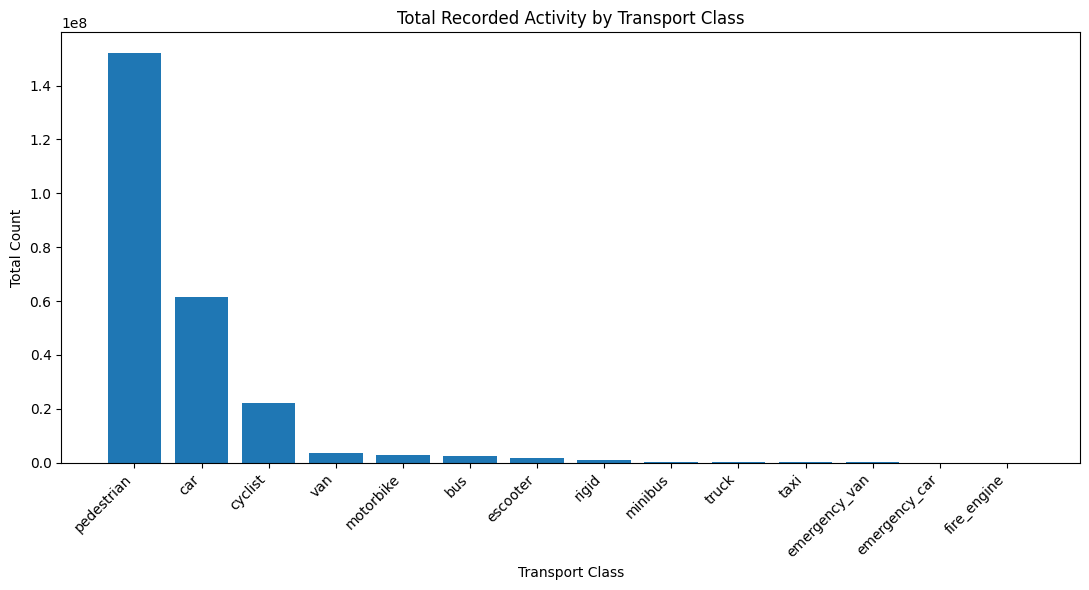

In [15]:
# CELL 8: Analyse transport classes and identify vehicle traffic

class_summary = {}

for file in activity_files:

    print("Analysing classes:", file.name)

    for chunk in pd.read_csv(
        file,
        chunksize=200_000,
        low_memory=False
    ):

        grouped = chunk.groupby("class")["count"].agg(
            ["count", "sum", "mean", "max"]
        )

        for activity_class, row in grouped.iterrows():

            if activity_class not in class_summary:
                class_summary[activity_class] = {
                    "Records": 0,
                    "Total_Count": 0,
                    "Maximum_5min_Count": 0
                }

            class_summary[activity_class]["Records"] += int(row["count"])
            class_summary[activity_class]["Total_Count"] += int(row["sum"])

            class_summary[activity_class]["Maximum_5min_Count"] = max(
                class_summary[activity_class]["Maximum_5min_Count"],
                int(row["max"])
            )


# Convert results to DataFrame
class_df = pd.DataFrame.from_dict(
    class_summary,
    orient="index"
).reset_index()

class_df = class_df.rename(
    columns={"index": "Transport_Class"}
)

# Calculate average count per observation
class_df["Average_Count_Per_Record"] = (
    class_df["Total_Count"] / class_df["Records"]
).round(2)

# Percentage of all counted activity
total_activity = class_df["Total_Count"].sum()

class_df["Percentage_of_Total_Activity"] = (
    class_df["Total_Count"] / total_activity * 100
).round(2)

class_df = class_df.sort_values(
    "Total_Count",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 70)
print("TRANSPORT CLASS SUMMARY")
print("=" * 70)

display(class_df)


# Define motor-vehicle classes relevant to traffic-volume analysis
vehicle_classes = [
    "car",
    "van",
    "bus",
    "motorbike",
    "rigid",
    "minibus",
    "truck",
    "taxi",
    "emergency_van",
    "emergency_car",
    "fire_engine"
]

vehicle_total = class_df.loc[
    class_df["Transport_Class"].isin(vehicle_classes),
    "Total_Count"
].sum()

print("\nTOTAL MOTOR-VEHICLE ACTIVITY")
print(f"{vehicle_total:,}")

print("\nNON-MOTOR VEHICLE CLASSES")
print(
    class_df.loc[
        ~class_df["Transport_Class"].isin(vehicle_classes),
        "Transport_Class"
    ].tolist()
)


# Visualise total activity by class
plt.figure(figsize=(11, 6))

plt.bar(
    class_df["Transport_Class"],
    class_df["Total_Count"]
)

plt.title("Total Recorded Activity by Transport Class")
plt.xlabel("Transport Class")
plt.ylabel("Total Count")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Processing temporal patterns: TransportActivityCount_2023-1.csv
Processing temporal patterns: TransportActivityCount_2023-2.csv
Processing temporal patterns: TransportActivityCount_2023-3.csv
Processing temporal patterns: TransportActivityCount_2023-4.csv
Processing temporal patterns: TransportActivityCount_2024-1.csv
Processing temporal patterns: TransportActivityCount_2024-2.csv
Processing temporal patterns: TransportActivityCount_2024-3.csv
Processing temporal patterns: TransportActivityCount_2024-4.csv
Processing temporal patterns: TransportActivityCount_2025-1.csv
Processing temporal patterns: TransportActivityCount_2025-2.csv
Processing temporal patterns: TransportActivityCount_2025-3.csv
Processing temporal patterns: TransportActivityCount_2025-4.csv
Processing temporal patterns: TransportActivityCount_2026-1.csv
Processing temporal patterns: TransportActivityCount_2026-2.csv

HOURLY ACTIVITY SUMMARY


,Hour,All_Activity_Total,All_Activity_Records,Average_All_Activity,Motor_Vehicle_Total,Motor_Vehicle_Records,Average_Motor_Vehicle_Count
0,0,3489534,549271,6.35,1497126,227994,6.57
1,1,2300896,447939,5.14,1092326,187799,5.82
2,2,1600939,375991,4.26,820362,166900,4.92
3,3,1268520,344018,3.69,669112,163904,4.08
4,4,1153193,360338,3.20,639413,177744,3.60
5,5,1909182,536909,3.56,988945,237571,4.16
6,6,4632834,833282,5.56,1925110,331342,5.81
7,7,9062880,1074269,8.44,2973734,407944,7.29
8,8,15332049,1206371,12.71,3720113,440757,8.44
9,9,12504154,1204649,10.38,3766354,461205,8.17



DAY-OF-WEEK SUMMARY


,Day,All_Activity_Total,All_Activity_Records,Average_All_Activity,Motor_Vehicle_Total,Motor_Vehicle_Records,Average_Motor_Vehicle_Count
0,Monday,31506374,3184974,9.89,9343260,1263725,7.39
1,Tuesday,34973185,3256712,10.74,10047033,1291517,7.78
2,Wednesday,35856955,3298441,10.87,10380333,1313232,7.90
3,Thursday,37192424,3325298,11.18,10866103,1324330,8.20
4,Friday,37576386,3338006,11.26,11262577,1338976,8.41
5,Saturday,38695113,3082287,12.55,10817760,1183525,9.14
6,Sunday,32176166,2861369,11.25,9066295,1049057,8.64


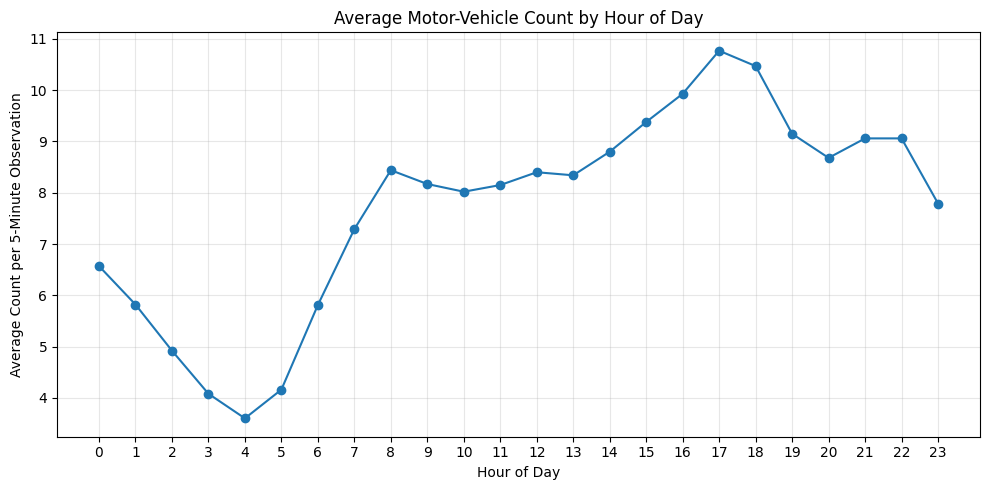

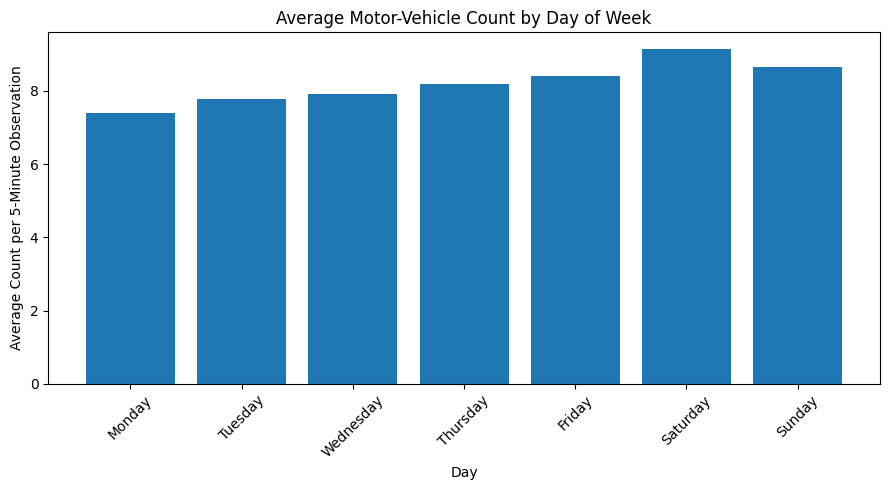

In [17]:
# CELL 9: Temporal analysis - hour of day and day of week

hour_total = Counter()
hour_records = Counter()

vehicle_hour_total = Counter()
vehicle_hour_records = Counter()

day_total = Counter()
day_records = Counter()

vehicle_day_total = Counter()
vehicle_day_records = Counter()

vehicle_classes = [
    "car",
    "van",
    "bus",
    "motorbike",
    "rigid",
    "minibus",
    "truck",
    "taxi",
    "emergency_van",
    "emergency_car",
    "fire_engine"
]

for file in activity_files:

    print("Processing temporal patterns:", file.name)

    for chunk in pd.read_csv(
        file,
        chunksize=200_000,
        low_memory=False
    ):

        # Convert timestamp
        timestamp = pd.to_datetime(
            chunk["from"],
            errors="coerce",
            utc=True
        )

        # Extract hour and day of week
        chunk["hour"] = timestamp.dt.hour
        chunk["day_of_week"] = timestamp.dt.day_name()

        # ---------------------------
        # ALL TRANSPORT ACTIVITY
        # ---------------------------

        hourly = chunk.groupby("hour")["count"].agg(
            ["sum", "count"]
        )

        for hour, row in hourly.iterrows():
            hour_total[hour] += int(row["sum"])
            hour_records[hour] += int(row["count"])

        daily = chunk.groupby("day_of_week")["count"].agg(
            ["sum", "count"]
        )

        for day, row in daily.iterrows():
            day_total[day] += int(row["sum"])
            day_records[day] += int(row["count"])

        # ---------------------------
        # MOTOR VEHICLES ONLY
        # ---------------------------

        vehicle_chunk = chunk[
            chunk["class"].isin(vehicle_classes)
        ]

        vehicle_hourly = vehicle_chunk.groupby("hour")["count"].agg(
            ["sum", "count"]
        )

        for hour, row in vehicle_hourly.iterrows():
            vehicle_hour_total[hour] += int(row["sum"])
            vehicle_hour_records[hour] += int(row["count"])

        vehicle_daily = vehicle_chunk.groupby(
            "day_of_week"
        )["count"].agg(["sum", "count"])

        for day, row in vehicle_daily.iterrows():
            vehicle_day_total[day] += int(row["sum"])
            vehicle_day_records[day] += int(row["count"])


# --------------------------------------------------
# CREATE HOURLY SUMMARY
# --------------------------------------------------

hourly_summary = pd.DataFrame({
    "Hour": range(24)
})

hourly_summary["All_Activity_Total"] = (
    hourly_summary["Hour"]
    .map(hour_total)
    .fillna(0)
)

hourly_summary["All_Activity_Records"] = (
    hourly_summary["Hour"]
    .map(hour_records)
    .fillna(0)
)

hourly_summary["Average_All_Activity"] = (
    hourly_summary["All_Activity_Total"] /
    hourly_summary["All_Activity_Records"]
).round(2)

hourly_summary["Motor_Vehicle_Total"] = (
    hourly_summary["Hour"]
    .map(vehicle_hour_total)
    .fillna(0)
)

hourly_summary["Motor_Vehicle_Records"] = (
    hourly_summary["Hour"]
    .map(vehicle_hour_records)
    .fillna(0)
)

hourly_summary["Average_Motor_Vehicle_Count"] = (
    hourly_summary["Motor_Vehicle_Total"] /
    hourly_summary["Motor_Vehicle_Records"]
).round(2)


print("\n" + "=" * 70)
print("HOURLY ACTIVITY SUMMARY")
print("=" * 70)

display(hourly_summary)


# --------------------------------------------------
# DAY-OF-WEEK SUMMARY
# --------------------------------------------------

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_summary = pd.DataFrame({
    "Day": day_order
})

day_summary["All_Activity_Total"] = (
    day_summary["Day"]
    .map(day_total)
    .fillna(0)
)

day_summary["All_Activity_Records"] = (
    day_summary["Day"]
    .map(day_records)
    .fillna(0)
)

day_summary["Average_All_Activity"] = (
    day_summary["All_Activity_Total"] /
    day_summary["All_Activity_Records"]
).round(2)

day_summary["Motor_Vehicle_Total"] = (
    day_summary["Day"]
    .map(vehicle_day_total)
    .fillna(0)
)

day_summary["Motor_Vehicle_Records"] = (
    day_summary["Day"]
    .map(vehicle_day_records)
    .fillna(0)
)

day_summary["Average_Motor_Vehicle_Count"] = (
    day_summary["Motor_Vehicle_Total"] /
    day_summary["Motor_Vehicle_Records"]
).round(2)


print("\n" + "=" * 70)
print("DAY-OF-WEEK SUMMARY")
print("=" * 70)

display(day_summary)


# --------------------------------------------------
# VISUALISE HOURLY MOTOR-VEHICLE PATTERN
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_summary["Hour"],
    hourly_summary["Average_Motor_Vehicle_Count"],
    marker="o"
)

plt.title("Average Motor-Vehicle Count by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Count per 5-Minute Observation")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# VISUALISE DAY-OF-WEEK PATTERN
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    day_summary["Day"],
    day_summary["Average_Motor_Vehicle_Count"]
)

plt.title("Average Motor-Vehicle Count by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Count per 5-Minute Observation")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# CELL 10: Export current analysis outputs and review dataset suitability

from pathlib import Path

# Create a folder for the outputs produced during the current analysis
output_folder = Path(
    r"C:\Users\LENOVO\Desktop\Project Urban\Data\EDA_Output\TransportActivityCount"
)

output_folder.mkdir(parents=True, exist_ok=True)

print("Output folder:")
print(output_folder)


# Save the useful tables created in the previous cells
coverage_df.to_csv(
    output_folder / "location_coverage_by_year.csv",
    index=False
)

class_df.to_csv(
    output_folder / "transport_class_summary.csv",
    index=False
)

hourly_summary.to_csv(
    output_folder / "hourly_activity_summary.csv",
    index=False
)

day_summary.to_csv(
    output_folder / "day_of_week_summary.csv",
    index=False
)

missing_summary.to_csv(
    output_folder / "missing_values_summary.csv",
    index=False
)


# Calculate a few useful quality measures
expected_interval_records = interval_counts.get(5.0, 0)

expected_interval_percentage = (
    expected_interval_records / total_checked * 100
)

missing_coordinate_rows = int(
    missing_values["CountLocationLat"]
)

missing_coordinate_percentage = (
    missing_coordinate_rows / total_checked * 100
)


print("\n" + "=" * 70)
print("CURRENT TRANSPORT ACTIVITY COUNT ANALYSIS")
print("=" * 70)


# Dataset size and time coverage
print("\nDATASET COVERAGE")

print("CSV files analysed:", len(activity_files))
print("Total records:", f"{total_checked:,}")
print("Unique count locations:", f"{len(unique_locations):,}")

print("Earliest observation:", earliest_date)
print("Latest observation:", latest_date)


# Structure
print("\nDATA STRUCTURE")

print(
    "All files use the same",
    len(sample_df.columns),
    "columns."
)

print(
    "Important fields include location ID, coordinates, "
    "timestamps, transport class and count."
)


# Data quality observations
print("\nDATA QUALITY")

print(
    "Potential duplicate observations:",
    f"{total_duplicates:,}"
)

print(
    "Negative count values:",
    f"{negative_counts:,}"
)

print(
    "Zero count values:",
    f"{zero_counts:,}"
)

print(
    "Rows with missing coordinates:",
    f"{missing_coordinate_rows:,}",
    f"({missing_coordinate_percentage:.4f}%)"
)

print(
    "Records using the expected 5-minute interval:",
    f"{expected_interval_records:,}",
    f"({expected_interval_percentage:.4f}%)"
)

print(
    "Records with unusual time intervals:",
    f"{invalid_intervals:,}"
)


# Monitoring-location coverage
print("\nCOUNT LOCATION COVERAGE")

for _, row in coverage_df.iterrows():

    print(
        f"{int(row['Year'])}: "
        f"{int(row['Unique_Count_Locations'])} locations"
    )


# Transport classes
print("\nTRANSPORT ACTIVITY")

print(
    "Total motor-vehicle count:",
    f"{vehicle_total:,}"
)

print("\nLargest transport classes:")

for _, row in class_df.head(5).iterrows():

    print(
        f"{row['Transport_Class']}: "
        f"{int(row['Total_Count']):,}"
    )


# Temporal patterns
print("\nTEMPORAL PATTERNS")

peak_hour_row = hourly_summary.loc[
    hourly_summary[
        "Average_Motor_Vehicle_Count"
    ].idxmax()
]

print(
    "Highest average motor-vehicle hour:",
    f"{int(peak_hour_row['Hour']):02d}:00",
    "-",
    peak_hour_row["Average_Motor_Vehicle_Count"]
)

peak_day_row = day_summary.loc[
    day_summary[
        "Average_Motor_Vehicle_Count"
    ].idxmax()
]

print(
    "Highest average motor-vehicle day:",
    peak_day_row["Day"],
    "-",
    peak_day_row["Average_Motor_Vehicle_Count"]
)


# Current assessment of how the dataset may support later work
print("\nCURRENT DATASET ASSESSMENT")

print(
    "- The data contains detailed 5-minute activity counts, "
    "which could support later hourly traffic aggregation."
)

print(
    "- Latitude and longitude are available for almost all records, "
    "which may allow comparison with Infrastructure Victoria locations."
)

print(
    "- Monitoring coverage changes substantially between years, "
    "so direct year-to-year comparisons require care."
)

print(
    "- A small number of unusual time intervals were identified "
    "and should be investigated during later preprocessing."
)

print(
    "- The available observations cover 2023 to May 2026, "
    "so additional historical data may be needed if a longer "
    "comparison period is required."
)

print(
    "- This dataset provides traffic/activity counts but does not "
    "directly contain parking occupancy information."
)


# Display saved files
print("\nOUTPUT FILES CREATED")

for file in sorted(output_folder.glob("*.csv")):
    print("-", file.name)


print("\nCurrent analysis outputs saved successfully.")

Output folder:
C:\Users\LENOVO\Desktop\Project Urban\Data\EDA_Output\TransportActivityCount

CURRENT TRANSPORT ACTIVITY COUNT ANALYSIS

DATASET COVERAGE
CSV files analysed: 14
Total records: 22,347,087
Unique count locations: 167
Earliest observation: 2023-01-01 00:00:00+00:00
Latest observation: 2026-05-11 15:55:00+00:00

DATA STRUCTURE
All files use the same 11 columns.
Important fields include location ID, coordinates, timestamps, transport class and count.

DATA QUALITY
Potential duplicate observations: 0
Negative count values: 0
Zero count values: 0
Rows with missing coordinates: 5,604 (0.0251%)
Records using the expected 5-minute interval: 22,346,837 (99.9989%)
Records with unusual time intervals: 250

COUNT LOCATION COVERAGE
2023: 32 locations
2024: 34 locations
2025: 85 locations
2026: 159 locations

TRANSPORT ACTIVITY
Total motor-vehicle count: 71,783,361

Largest transport classes:
pedestrian: 152,184,217
car: 61,382,705
cyclist: 22,203,577
van: 3,652,765
motorbike: 2,652,495